In [1]:
import numpy as np
import mne
import os
import pywt
import scipy.io as sio
from scipy import signal
from scipy.signal import hilbert
from matplotlib.ticker import ScalarFormatter
from statsmodels.tsa.stattools import acf
from scipy.ndimage import gaussian_filter1d


from NeuralFieldManifold.models import AR, TAR
from NeuralFieldManifold.embedders import embed
from NeuralFieldManifold.pub_utils import *

# capture future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

set_pub_style()

In [2]:
import numpy as np
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import plotly.graph_objects as go
from NeuralFieldManifold.fits.two_torus import two_torus_fit, plot_two_torus_fit

/home/potato/miniconda3/envs/manifold/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Moneky

In [12]:
def sweep_fits(windows, lam=1, n_jobs=-1):
    fits = Parallel(n_jobs=n_jobs)(
        delayed(two_torus_fit)(w['points'], lam=lam)
        for w in windows
    )
    return [{**w, **f} for w, f in zip(windows, fits)]

def make_windows(xs, Fs, embedding_dim, tau, starts_sec, window_sec=2):
    window_samples = int(window_sec * Fs)
    windows = []
    for t in starts_sec:
        start = int(t * Fs)
        segment = xs[start:start + window_samples]
        pts = np.asarray(embed(segment, embedding_dim, tau))
        windows.append({
            'points': pts,
            'start_sec': t,
            'end_sec': t + window_sec,
        })
    return windows

In [13]:
monkey_xs, monkey_Fs, monkey_tau = np.load("data/monkey_lfp.npz").values()

# xs is -something to +something. we need it to -1 to +1 for comparablility
monkey_xs_rescaled = (monkey_xs - np.min(monkey_xs)) / (np.max(monkey_xs) - np.min(monkey_xs)) * 2 - 1
monkey_xs.shape, monkey_Fs, monkey_tau

((10000,), array(500), array(30))

In [14]:
# Time x Tau sweep with fixed 5-second windows
monkey_window_size = 5.0
monkey_time_step = 0.05
monkey_embedding_dim = 3

monkey_Fs_scalar = float(np.asarray(monkey_Fs).squeeze())
monkey_duration_sec = len(monkey_xs_rescaled) / monkey_Fs_scalar
monkey_max_start = max(monkey_duration_sec - monkey_window_size, 0.0)
monkey_time_starts_grid = np.arange(0.0, monkey_max_start + 1e-9, monkey_time_step)

monkey_max_tau = int((monkey_window_size * monkey_Fs_scalar - 1) // (monkey_embedding_dim - 1))
monkey_tau_values_grid = np.arange(1, min(100, monkey_max_tau + 1), 1)

monkey_all_windows = []
for j, tau_val in enumerate(tqdm(monkey_tau_values_grid, desc="Building windows")):
    tau_windows = make_windows(
        monkey_xs_rescaled,
        Fs=monkey_Fs_scalar,
        embedding_dim=monkey_embedding_dim,
        tau=int(tau_val),
        starts_sec=monkey_time_starts_grid,
        window_sec=monkey_window_size,
    )
    for i, w in enumerate(tau_windows):
        w["time_idx"] = i
        w["tau_idx"] = j
        monkey_all_windows.append(w)

monkey_all_fits = sweep_fits(monkey_all_windows)

monkey_err_mat = np.full((len(monkey_time_starts_grid), len(monkey_tau_values_grid)), np.nan)
monkey_frac_mat = np.full_like(monkey_err_mat, np.nan)

for fit in monkey_all_fits:
    i = fit["time_idx"]
    j = fit["tau_idx"]
    monkey_err_mat[i, j] = fit["mean_error"]
    monkey_frac_mat[i, j] = fit["frac_inside"]

Building windows: 100%|██████████| 99/99 [00:00<00:00, 250.56it/s]


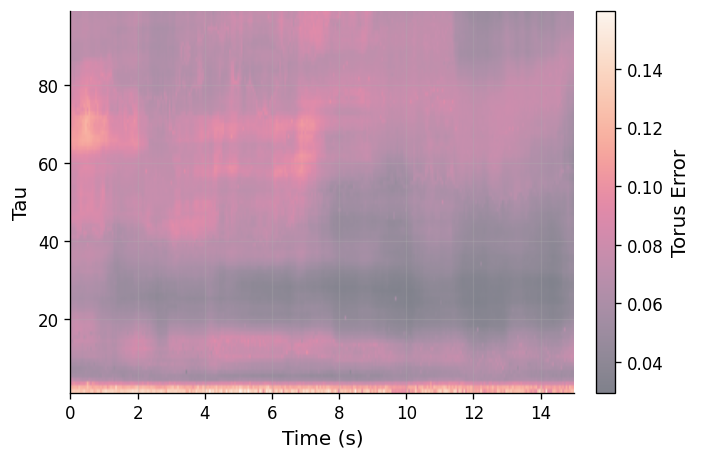

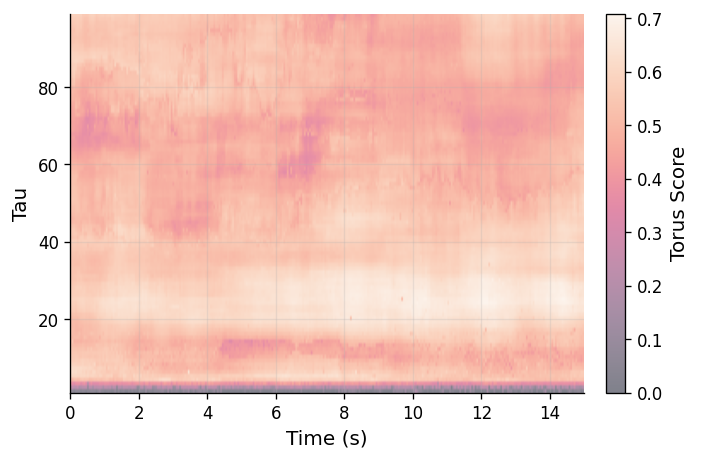

In [ ]:
import seaborn as sns

dark_red_cmap = sns.color_palette("rocket", as_cmap=True)

monkey_heatmaps = [
    ("Torus Error", monkey_err_mat, "Torus Error"),
    ("Torus Score", monkey_frac_mat, "Torus Score"),
]

for _, mat, cbar_label in monkey_heatmaps:
    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(
        mat.T,
        origin="lower",
        aspect="auto",
        alpha=0.8,
        extent=[monkey_time_starts_grid[0], monkey_time_starts_grid[-1], monkey_tau_values_grid[0], monkey_tau_values_grid[-1]],
        cmap=dark_red_cmap,
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Tau")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)
    plt.tight_layout()
    plt.show()

# Mice

In [7]:
from NeuralFieldManifold.fits import one_torus_fit, plot_one_torus_fit

In [8]:
def sweep_fits(windows, lam=1.0, n_jobs=-1):
    fits = Parallel(n_jobs=n_jobs)(
        delayed(two_torus_fit)(w['points'], lam=lam)
        for w in windows
    )
    return [{**w, **f} for w, f in zip(windows, fits)]

def make_windows(xs, Fs, embedding_dim, tau, starts_sec, window_sec=2):
    window_samples = int(window_sec * Fs)
    windows = []
    for t in starts_sec:
        start = int(t * Fs)
        segment = xs[start:start + window_samples]
        pts = np.asarray(embed(segment, embedding_dim, tau))
        windows.append({
            'points': pts,
            'start_sec': t,
            'end_sec': t + window_sec,
        })
    return windows

In [9]:
mice_xs, mice_Fs, mice_tau = np.load("data/mice_lfp.npz").values()
mice_xs.shape, mice_Fs, mice_tau

((2500,), array(500.), array(10))

In [10]:
# Time x Tau sweep with fixed 1-second windows
mice_xs_rescaled = (mice_xs - np.min(mice_xs)) / (np.max(mice_xs) - np.min(mice_xs)) * 2 - 1

mice_window_size = 1.0
mice_time_step = 0.05
mice_embedding_dim = 3

mice_Fs_scalar = float(np.asarray(mice_Fs).squeeze())
mice_duration_sec = len(mice_xs_rescaled) / mice_Fs_scalar
mice_max_start = max(mice_duration_sec - mice_window_size, 0.0)
mice_time_starts_grid = np.arange(0.0, mice_max_start + 1e-9, mice_time_step)

mice_max_tau = int((mice_window_size * mice_Fs_scalar - 1) // (mice_embedding_dim - 1))
if mice_max_tau < 1:
    raise ValueError("Window size is too short for the selected embedding dimension.")
mice_tau_values_grid = np.arange(1, min(100, mice_max_tau + 1), 1)

mice_all_windows = []
for j, tau_val in enumerate(tqdm(mice_tau_values_grid, desc="Building windows")):
    tau_windows = make_windows(
        mice_xs_rescaled,
        Fs=mice_Fs_scalar,
        embedding_dim=mice_embedding_dim,
        tau=int(tau_val),
        starts_sec=mice_time_starts_grid,
        window_sec=mice_window_size,
    )
    for i, w in enumerate(tau_windows):
        w["time_idx"] = i
        w["tau_idx"] = j
        mice_all_windows.append(w)

mice_all_fits = sweep_fits(mice_all_windows)

mice_err_mat = np.full((len(mice_time_starts_grid), len(mice_tau_values_grid)), np.nan)
mice_frac_mat = np.full_like(mice_err_mat, np.nan)

for fit in mice_all_fits:
    i = fit["time_idx"]
    j = fit["tau_idx"]
    mice_err_mat[i, j] = fit["mean_error"]
    mice_frac_mat[i, j] = fit["frac_inside"]

Building windows: 100%|██████████| 99/99 [00:01<00:00, 60.11it/s]


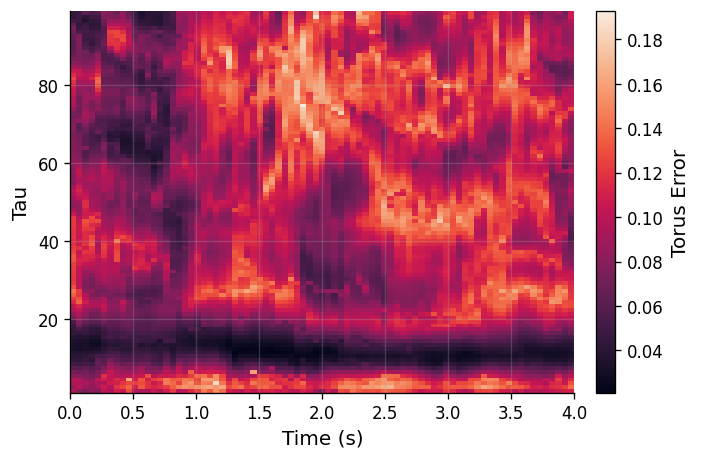

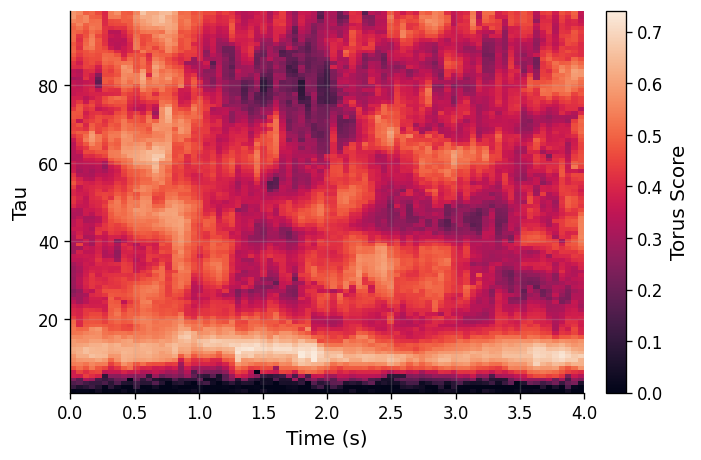

In [34]:
mice_heatmaps = [
    ("Torus Error", mice_err_mat, "Torus Error"),
    ("Torus Score", mice_frac_mat, "Torus Score"),
]

for _, mat, cbar_label in mice_heatmaps:
    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(
        mat.T,
        origin="lower",
        aspect="auto",
        extent=[mice_time_starts_grid[0], mice_time_starts_grid[-1], mice_tau_values_grid[0], mice_tau_values_grid[-1]],
        cmap="rocket",
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Tau")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)
    plt.tight_layout()
    plt.show()